In [1]:
import pandas as pd
import numpy as np
import multiprocessing
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn import metrics
import gc
from time import time
import datetime
from tqdm import tqdm_notebook
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold,GroupKFold
from sklearn.metrics import roc_auc_score
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
warnings.simplefilter('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv('Datasets/train_dataset_final1.csv')
test_df = pd.read_csv('Datasets/validate_dataset_final.csv')
df.isnull().sum()

Customer_ID             0
marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_0                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64

In [3]:
# Drop all rows with Nan in age column
df = df.dropna(subset=['age'])
test_df = test_df.dropna(subset=['age'])

In [4]:
df.drop(columns=['Customer_ID'], inplace=True)
# test_df.drop(columns=['Customer_ID'], inplace=True)

In [5]:
def credit_card_feature_engineering(df):
    """
    Perform comprehensive feature engineering on credit card default dataset

    Args:
        df: DataFrame with credit card default data
    
    Returns:
        DataFrame with additional engineered features
    """
    df_fe = df.copy()
    
    # Payment delay features
    payment_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
    df_fe['count_delayed_payments'] = (df_fe[payment_cols] > 0).sum(axis=1)
    df_fe['max_payment_delay'] = df_fe[payment_cols].max(axis=1)
    df_fe['avg_payment_delay'] = df_fe[payment_cols].mean(axis=1)
    df_fe['has_severe_delay'] = (df_fe[payment_cols] >= 2).any(axis=1).astype(int)
    
    # Bill and payment amount features
    bill_cols = ['Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6']
    pay_cols = ['pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']
    
    df_fe['total_bill_amount'] = df_fe[bill_cols].sum(axis=1)
    df_fe['total_payment_amount'] = df_fe[pay_cols].sum(axis=1)
    df_fe['total_payment_ratio'] = df_fe['total_payment_amount'] / df_fe['total_bill_amount'].replace(0, np.nan)
    df_fe['total_payment_ratio'] = df_fe['total_payment_ratio'].fillna(0)
    
    # Variability features
    df_fe['bill_amount_std'] = df_fe[bill_cols].std(axis=1)
    df_fe['payment_amount_std'] = df_fe[pay_cols].std(axis=1)
    df_fe['recent_payment_ratio'] = (df_fe['pay_amt1'] + df_fe['pay_amt2']) / (df_fe['total_payment_amount'] + 1)
    
    # Credit utilization patterns
    df_fe['avg_bill_amount'] = df_fe[bill_cols].mean(axis=1)
    df_fe['credit_utilization'] = df_fe['avg_bill_amount'] / df_fe['LIMIT_BAL']
    df_fe['max_credit_utilization'] = df_fe[bill_cols].max(axis=1) / df_fe['LIMIT_BAL']
    
    # Payment behavior patterns
    df_fe['payment_consistency'] = 1 - (df_fe['payment_amount_std'] / (df_fe['total_payment_amount'] + 1))
    df_fe['consecutive_delays'] = 0
    for i in range(len(payment_cols) - 1):
        df_fe['consecutive_delays'] += ((df_fe[payment_cols[i]] > 0) & (df_fe[payment_cols[i+1]] > 0)).astype(int)
    
    # Financial stress indicators
    df_fe['bill_increasing_trend'] = (df_fe['Bill_amt1'] > df_fe['Bill_amt6']).astype(int)
    df_fe['payment_decreasing_trend'] = (df_fe['pay_amt1'] < df_fe['pay_amt6']).astype(int)
    df_fe['financial_stress_score'] = (df_fe['has_severe_delay'] + 
                                       df_fe['bill_increasing_trend'] + 
                                       df_fe['payment_decreasing_trend'] + 
                                       (df_fe['credit_utilization'] > 0.8).astype(int))
    
    # Monthly payment patterns
    for i in range(1, 7):
        df_fe[f'payment_to_bill_ratio_{i}'] = df_fe[f'pay_amt{i}'] / (df_fe[f'Bill_amt{i}'] + 1)
    
    # Education and demographic interactions
    df_fe['high_education_low_limit'] = ((df_fe['education'] <= 2) & (df_fe['LIMIT_BAL'] < 50000)).astype(int)
    df_fe['married_female'] = ((df_fe['marriage'] == 1) & (df_fe['sex'] == 0)).astype(int)
    
    # Risk indicators
    df_fe['zero_payment_months'] = (df_fe[pay_cols] == 0).sum(axis=1)
    df_fe['high_utilization_low_payment'] = ((df_fe['credit_utilization'] > 0.7) & 
                                             (df_fe['total_payment_ratio'] < 0.1)).astype(int)
    
    df['Payment_Value'] = df['pay_0'] + df['pay_2'] + df['pay_3'] + df['pay_4'] + df['pay_5'] + df['pay_6']
    df['Dues'] = (df['Bill_amt1']+df['Bill_amt2']+df['Bill_amt3']+df['Bill_amt4']+df['Bill_amt5']+df['Bill_amt6'])-(df['pay_amt1']+df['pay_amt2']+df['pay_amt3']+df['pay_amt4']+df['pay_amt5']+df['pay_amt6'])
    
    return df_fe


df_fe = credit_card_feature_engineering(df)
test_fe = credit_card_feature_engineering(test_df)

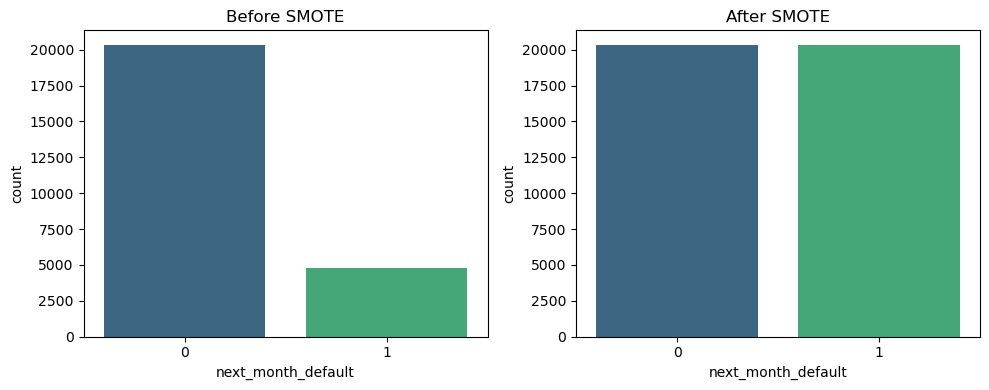

In [6]:
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
X = df_fe.drop(columns=['next_month_default'])
y = df_fe['next_month_default']

X_final_test = test_fe.drop(columns=['Customer_ID'])


scaler = StandardScaler()
X = scaler.fit_transform(X)
X_final_test = scaler.transform(X_final_test)


smote = SMOTE()
X_smote, y_smote= smote.fit_resample(X, y)

# Plot before and after
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, y, title in zip(axs, [y, y_smote], ['Before SMOTE', 'After SMOTE']):
    sns.countplot(x=y, ax=ax, palette='viridis')
    ax.set_title(title)
plt.tight_layout()
plt.show()

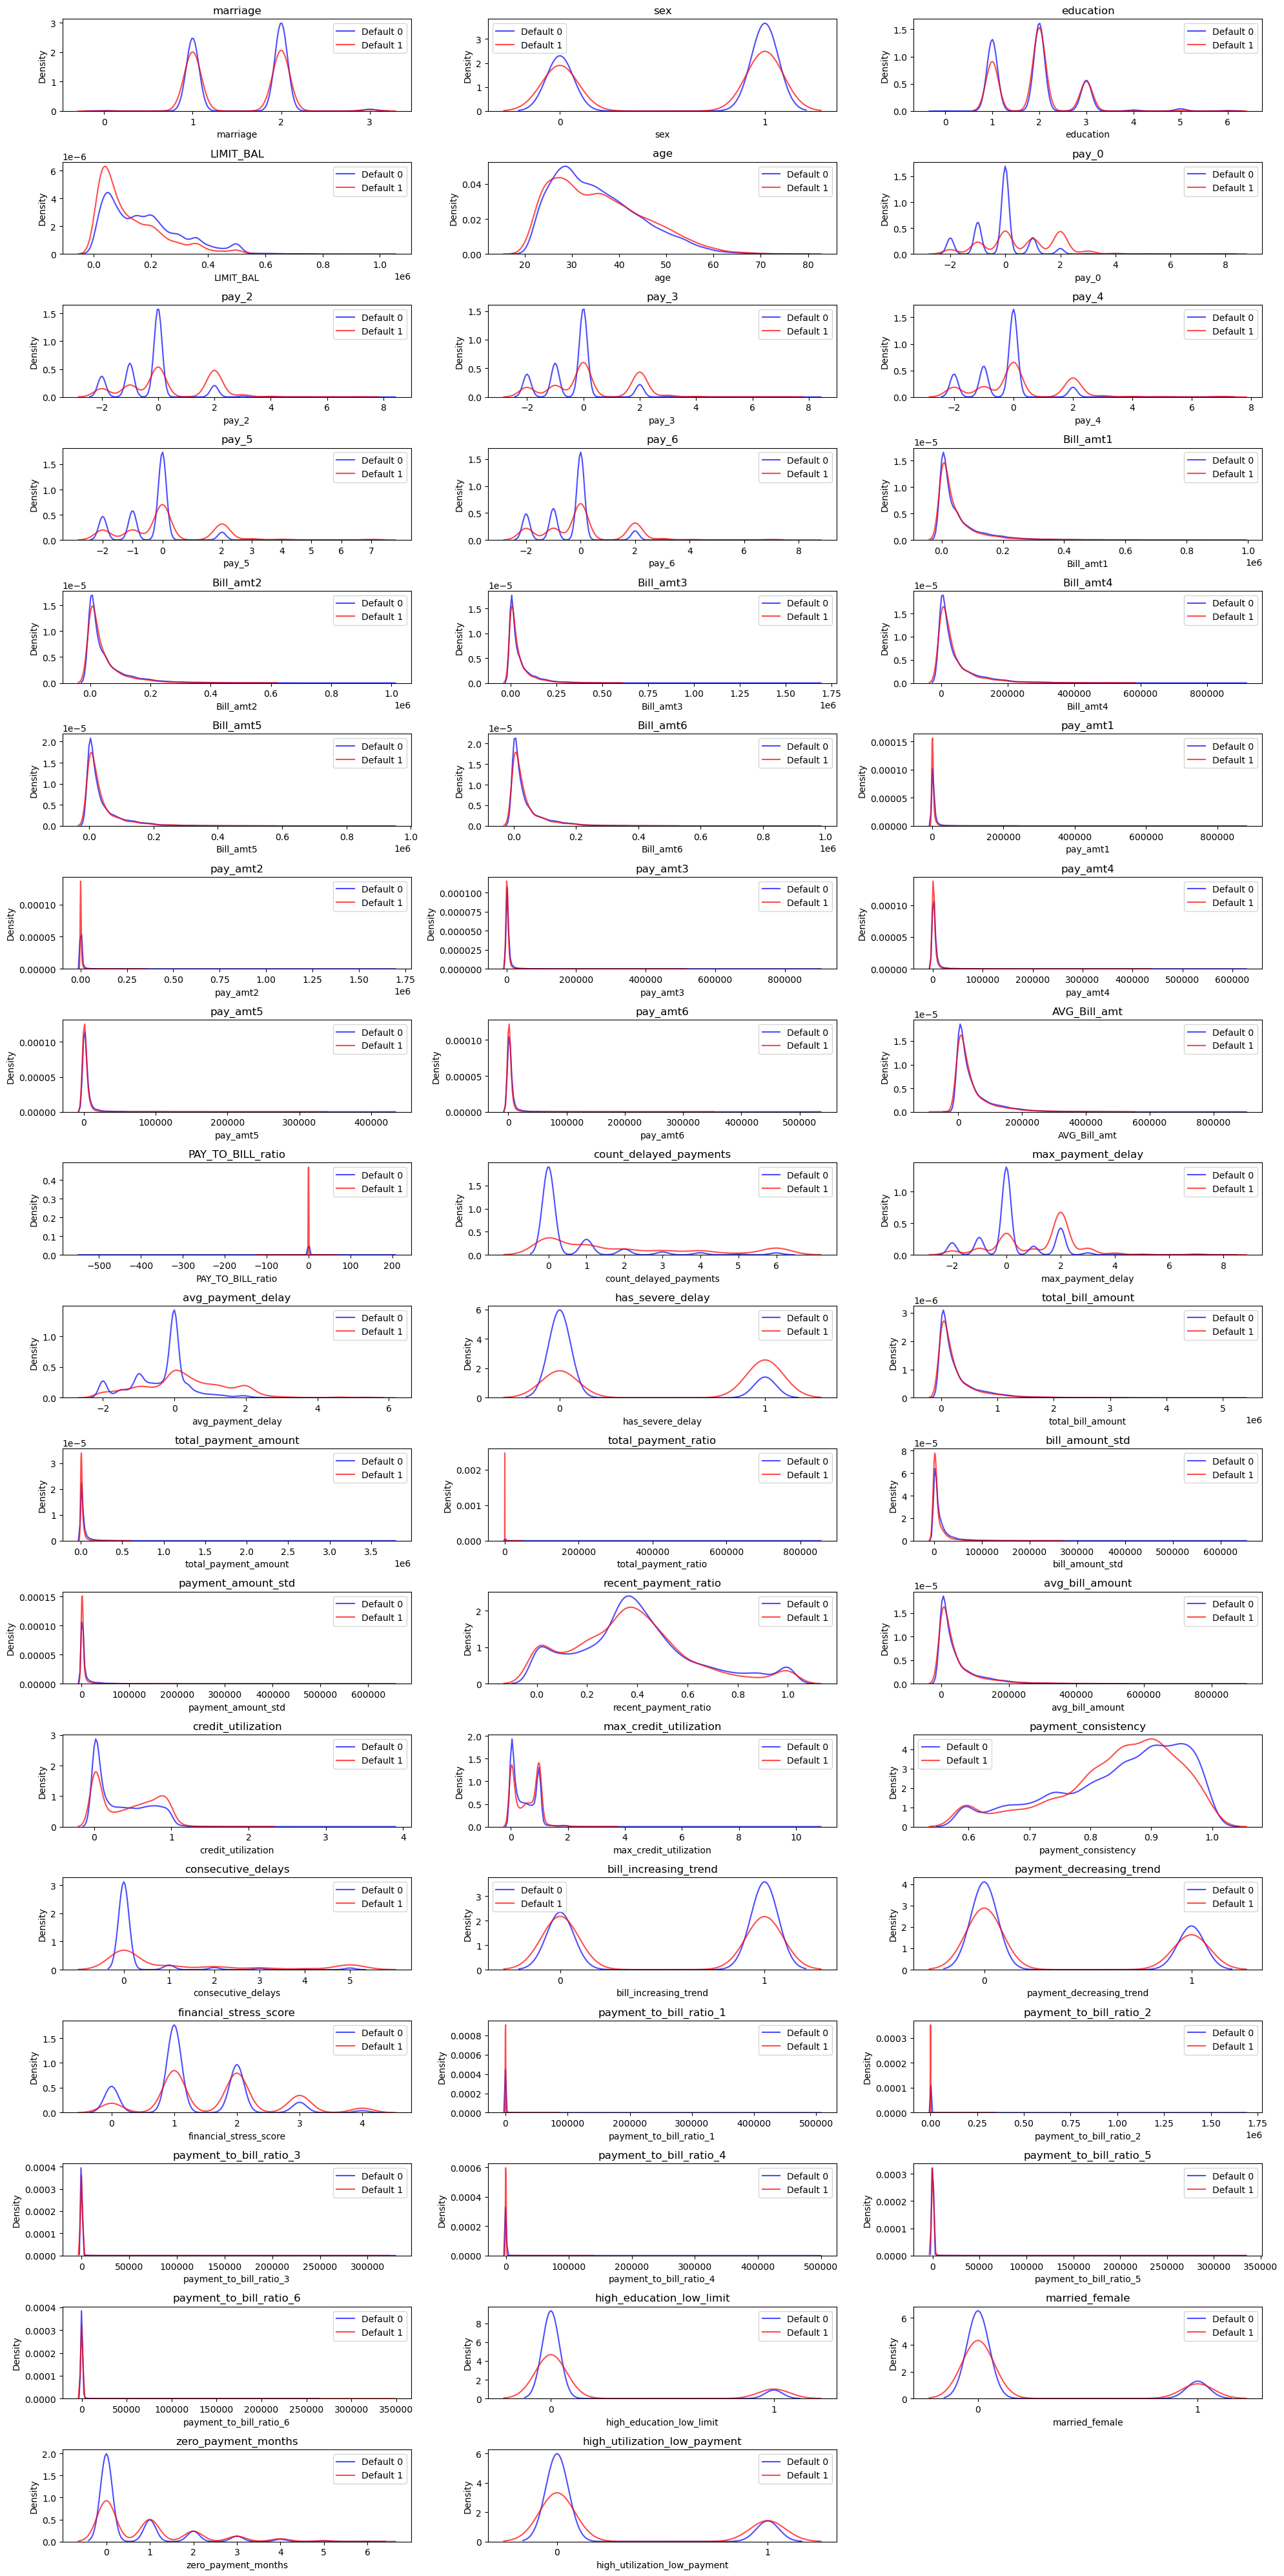

In [7]:
features = df_fe.drop(columns='next_month_default').columns
n_cols = 3
n_rows = -(-len(features) // n_cols)

plt.figure(figsize=(20, 40))
for i, f in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    for cls, color in zip([0, 1], ['blue', 'red']):
        sns.kdeplot(df_fe[df_fe['next_month_default'] == cls][f], label=f'Default {cls}', alpha=0.7, color=color)
    plt.title(f)
    plt.xlabel(f)
    if df_fe[f].nunique() < 10:
        plt.xticks(sorted(df_fe[f].unique()))
    plt.legend()
plt.tight_layout()
plt.show()

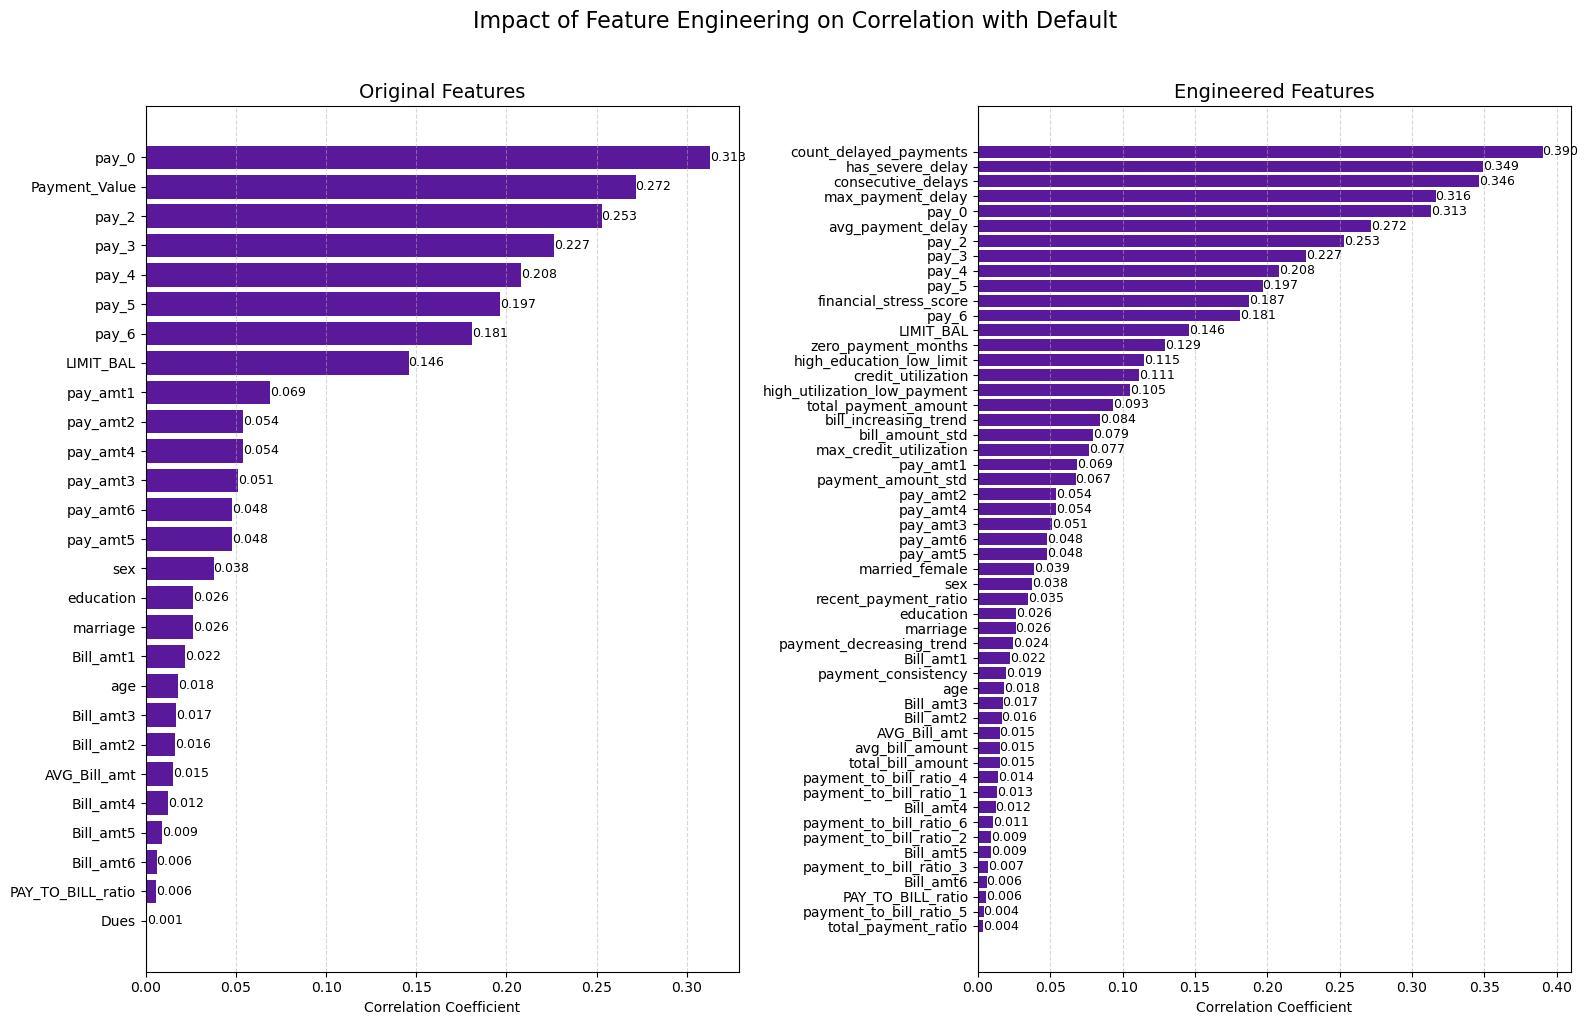

In [8]:
# Calculate correlations with the target variable
corr = df.drop(columns=['next_month_default']).corrwith(df['next_month_default']).abs().sort_values(ascending=True)
corr_fe = df_fe.drop(columns=['next_month_default']).corrwith(df_fe['next_month_default']).abs().sort_values(ascending=True)

def plot_corr(ax, corr, title):
    colors = ['#5a189a' if x > 0 else '#c77dff' for x in corr]
    bars = ax.barh(corr.index, corr.values, color=colors)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Correlation Coefficient')
    ax.axvline(0, color='black', linestyle='-', alpha=0.3)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    for bar in bars:
        w = bar.get_width()
        ax.text(w if w > 0 else w - 0.05, bar.get_y() + bar.get_height()/2,
                f'{w:.3f}', va='center', ha='left' if w > 0 else 'right', fontsize=9)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
plot_corr(ax1, corr, 'Original Features')
plot_corr(ax2, corr_fe, 'Engineered Features')
plt.suptitle('Impact of Feature Engineering on Correlation with Default', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42, stratify = y)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, f1_score,fbeta_score, recall_score,precision_score, confusion_matrix, classification_report, roc_auc_score, make_scorer

In [11]:
def get_f2_score(y_true, y_pred):
    """
    Calculate F2 score which emphasizes recall more than precision.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
    
    Returns:
        F2 score
    """
    return fbeta_score(y_true, y_pred, beta=2)

In [12]:
def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] 

    print(f"\n==== {name} ====")
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
    print("Classification Report:\n", classification_report(y, y_pred))
    print(f"Accuracy     : {accuracy_score(y, y_pred):.4f}")
    print(f"Precision    : {precision_score(y, y_pred):.4f}")
    print(f"Recall       : {recall_score(y, y_pred):.4f}")
    print(f"F1 Score     : {f1_score(y, y_pred):.4f}")
    print(f"F2 Score     : {fbeta_score(y, y_pred, beta=2):.4f}")
    print(f"ROC-AUC      : {roc_auc_score(y, y_proba):.4f}")
    print("-" * 40)

In [13]:
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    evaluate_model(model.__class__.__name__, model, X_val, y_val)

# Expanded model dictionary with more algorithms
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# Store results for comparison
results = {}

print("Training and evaluating all models...")
print("=" * 50)

for name, model in models.items():
    print(f"\nTraining and evaluating {name}...")
    model.fit(X_train, y_train)
    
    # Get predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'F2_Score': f2,
        'ROC_AUC': roc_auc
    }
    
    evaluate_model(name, model, X_test, y_test)

# Find best model for each metric
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

# Create comparison DataFrame
comparison_df = pd.DataFrame(results).T
print(comparison_df.round(4))

print("\n" + "=" * 40)
print("BEST MODELS BY METRIC:")
print("=" * 40)

for metric in comparison_df.columns:
    best_model = comparison_df[metric].idxmax()
    best_score = comparison_df[metric].max()
    print(f"{metric:20}: {best_model:20} ({best_score:.4f})")

# Overall best model (weighted by F2 score for default prediction importance)
print("\n" + "=" * 40)
print("RECOMMENDED MODEL:")
print("=" * 40)
best_f2_model = comparison_df['F2_Score'].idxmax()
print(f"Best F2 Score Model: {best_f2_model}")
print(f"F2 Score: {comparison_df.loc[best_f2_model, 'F2_Score']:.4f}")
print(f"Recall: {comparison_df.loc[best_f2_model, 'Recall']:.4f}")
print(f"ROC-AUC: {comparison_df.loc[best_f2_model, 'ROC_AUC']:.4f}")


Training and evaluating all models...

Training and evaluating Logistic Regression...

==== Logistic Regression ====
Confusion Matrix:
 [[3174  894]
 [1554 2513]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.78      0.72      4068
           1       0.74      0.62      0.67      4067

    accuracy                           0.70      8135
   macro avg       0.70      0.70      0.70      8135
weighted avg       0.70      0.70      0.70      8135

Accuracy     : 0.6991
Precision    : 0.7376
Recall       : 0.6179
F1 Score     : 0.6725
F2 Score     : 0.6386
ROC-AUC      : 0.7697
----------------------------------------

Training and evaluating Decision Tree...

==== Decision Tree ====
Confusion Matrix:
 [[3237  831]
 [ 646 3421]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81      4068
           1       0.80      0.84      0.82      4067

    accuracy

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score, f1_score, recall_score, precision_score, roc_auc_score, accuracy_score
from xgboost import XGBClassifier
import pandas as pd

# Define F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

# Model
xgb = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)

# RandomizedSearchCV
search = RandomizedSearchCV(xgb, param_grid, n_iter=500, scoring=f2_scorer, cv=5, random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

# Best model
best_model = search.best_estimator_
best_model.fit(X_train, y_train)

# Evaluation
def get_metrics(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        'F2_Score': fbeta_score(y, pred, beta=2),
        'F1_Score': f1_score(y, pred),
        'Recall': recall_score(y, pred),
        'Precision': precision_score(y, pred),
        'ROC_AUC': roc_auc_score(y, proba),
        'Accuracy': accuracy_score(y, pred)
    }

metrics_tuned = get_metrics(best_model, X_test, y_test)
metrics_orig = get_metrics(XGBClassifier(eval_metric='logloss', random_state=42).fit(X_train, y_train), X_test, y_test)

# Comparison
comparison = pd.DataFrame({
    'Original': metrics_orig,
    'Tuned': metrics_tuned,
    'Improvement': {k: metrics_tuned[k] - metrics_orig[k] for k in metrics_orig}
})

print("\nBest Params:", search.best_params_)
print("\nMetric Comparison:\n", comparison.round(4))
print("\nTuned XGBoost model saved.")

Fitting 5 folds for each of 500 candidates, totalling 2500 fits

Best Params: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Metric Comparison:
            Original   Tuned  Improvement
F2_Score     0.8631  0.8727       0.0096
F1_Score     0.8867  0.8923       0.0056
Recall       0.8480  0.8601       0.0120
Precision    0.9291  0.9271      -0.0020
ROC_AUC      0.9474  0.9507       0.0033
Accuracy     0.8917  0.8963       0.0045

Tuned XGBoost model saved.


In [ ]:
# Using XGboost with params
Best_Params = {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

# perfrom threshold tuning for F2 score
def find_best_threshold(y_true, y_proba, beta=2):
    thresholds = np.arange(0.0, 1.01, 0.01)
    best_f2 = 0
    best_threshold = 0.5
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        f2 = fbeta_score(y_true, y_pred, beta=beta)
        if f2 > best_f2:
            best_f2 = f2
            best_threshold = threshold
            
    return best_threshold, best_f2

# Train the model with the best parameters
xgb_tuned = XGBClassifier(**Best_Params, eval_metric='logloss', random_state=42)
xgb_tuned.fit(X_train, y_train)

# Get the scores
y_proba = xgb_tuned.predict_proba(X_test)[:, 1]
best_threshold, best_f2 = find_best_threshold(y_test, y_proba)
print(f"Best Threshold: {best_threshold:.2f}, Best F2 Score: {best_f2:.4f}")


Best Threshold: 0.16, Best F2 Score: 0.8951


In [17]:
# Get prediction for X_final_test and save it to a CSV file

y_final_proba = xgb_tuned.predict_proba(X_final_test)[:, 1]
y_final_pred = (y_final_proba >= 0.16).astype(int)
submission = pd.DataFrame({
    'Customer_ID': test_df['Customer_ID'],
    'next_month_default': y_final_pred
})
submission.to_csv('submission.csv', index=False)
print("Submission file created: submission.csv")

Submission file created: submission.csv
